In [ ]:
import pandas as pd
import os
import joblib
import math

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [3]:
data_path = "cleaned_EMI_dataset.csv"

if not os.path.exists(data_path):
    raise FileNotFoundError(f"Dataset not found at {data_path}")

df = pd.read_csv(data_path, low_memory=False)

print("Dataset loaded:", df.shape)

df.head()

Dataset loaded: (404800, 44)


,age,monthly_salary,years_of_employment,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,...,company_type_Small,company_type_Startup,house_type_Own,house_type_Rented,emi_scenario_Education EMI,emi_scenario_Home Appliances EMI,emi_scenario_Personal Loan EMI,emi_scenario_Vehicle EMI,emi_eligibility_High_Risk,emi_eligibility_Not_Eligible
0,38.0,82600.0,0.9,20000.0,3,2,0.0,0.0,7200.0,19500.0,...,False,False,False,True,False,False,True,False,False,True
1,38.0,21500.0,7.0,0.0,2,1,5100.0,0.0,1400.0,5400.0,...,False,False,False,False,False,False,False,False,False,True
2,38.0,86100.0,5.8,0.0,4,3,0.0,0.0,10200.0,19400.0,...,False,True,True,False,True,False,False,False,False,False
3,58.0,66800.0,2.2,0.0,5,4,11400.0,0.0,6200.0,11900.0,...,False,False,True,False,False,False,False,True,False,False
4,48.0,57300.0,3.4,0.0,4,3,9400.0,21300.0,3600.0,16200.0,...,False,False,False,False,False,True,False,False,False,True


In [4]:
target = "max_monthly_emi"

if target not in df.columns:
    raise ValueError(
        f"Target column '{target}' not found. Columns available: {df.columns.tolist()}"
    )

print("Target column confirmed:", target)

Target column confirmed: max_monthly_emi


In [5]:
exclude_cols = ["emi_eligibility", "max_monthly_emi"]

base_features = [col for col in df.columns if col not in exclude_cols]

X = df[base_features].copy()
y = df[target]

print("Number of features:", len(base_features))

Number of features: 43


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (323840, 43)
Test shape: (80960, 43)


In [8]:
model = LinearRegression()

print("Training Linear Regression model...")

model.fit(X_train, y_train)

Training Linear Regression model...


LinearRegression()

In [9]:
y_pred = model.predict(X_test)

In [10]:
mse = mean_squared_error(y_test, y_pred)
rmse = math.sqrt(mse)

mae = mean_absolute_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

# MAPE
mape = (abs((y_test - y_pred) / y_test)).mean() * 100

print("Regression Evaluation Metrics")
print("-----------------------------")

print("RMSE :", rmse)
print("MAE  :", mae)
print("R²   :", r2)
print("MAPE :", mape)

Regression Evaluation Metrics
-----------------------------
RMSE : 3861.293660954981
MAE  : 2771.2228481285865
R²   : 0.7474510820116391
MAPE : 166.41460674245914


In [11]:
os.makedirs("models", exist_ok=True)

joblib.dump(model, "models/linear_regression.pkl")
joblib.dump(list(X.columns), "models/train_columns_reg.pkl")

print("Linear Regression model saved successfully.")

Linear Regression model saved successfully.


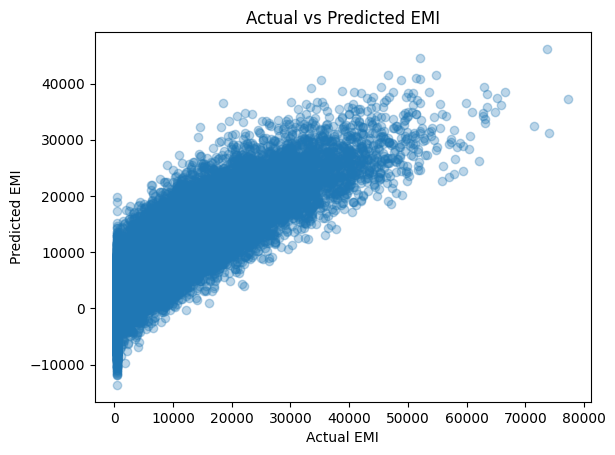

In [12]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual EMI")
plt.ylabel("Predicted EMI")
plt.title("Actual vs Predicted EMI")
plt.show()